In [1]:
!pip install opencv-python

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Video_Playback.mp4 to Video_Playback.mp4


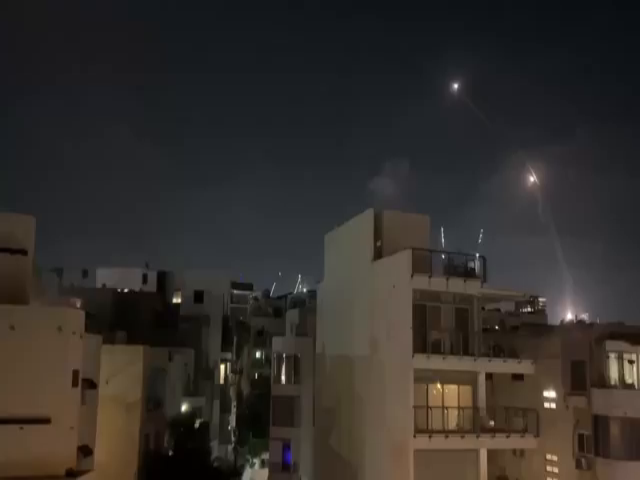

/tmp/ipykernel_640/4013806378.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.predicted = (int(prediction[0]), int(prediction[1]))


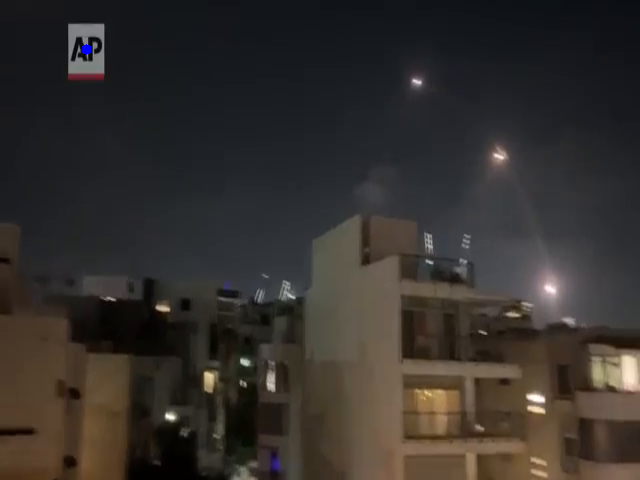

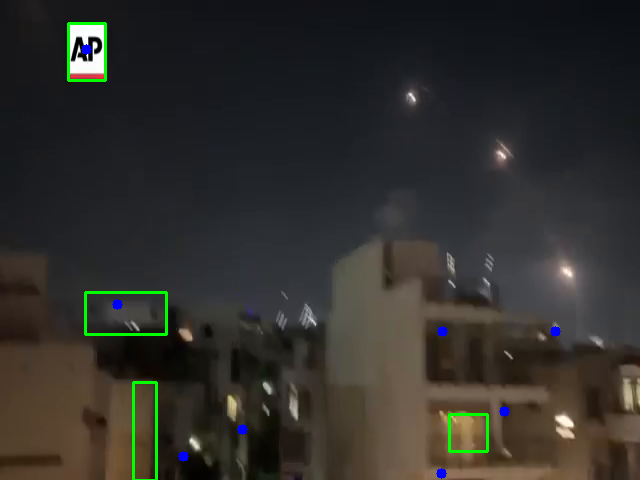

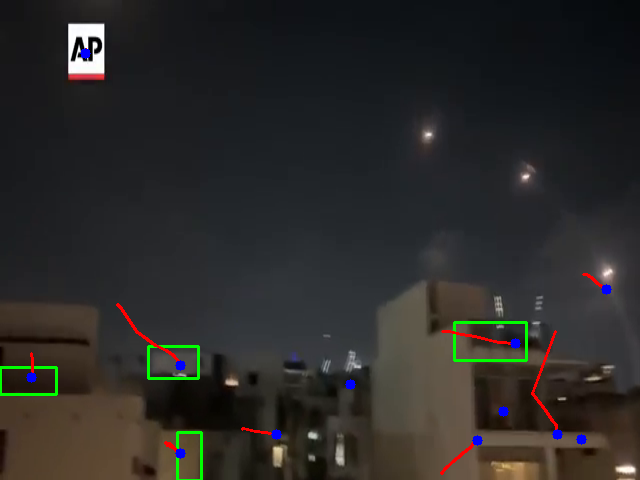

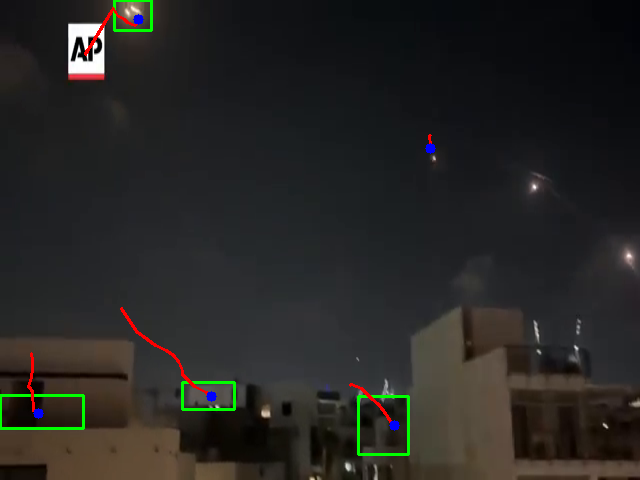

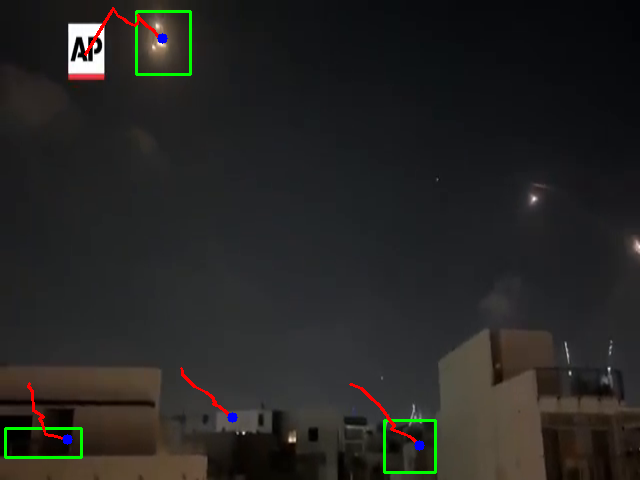

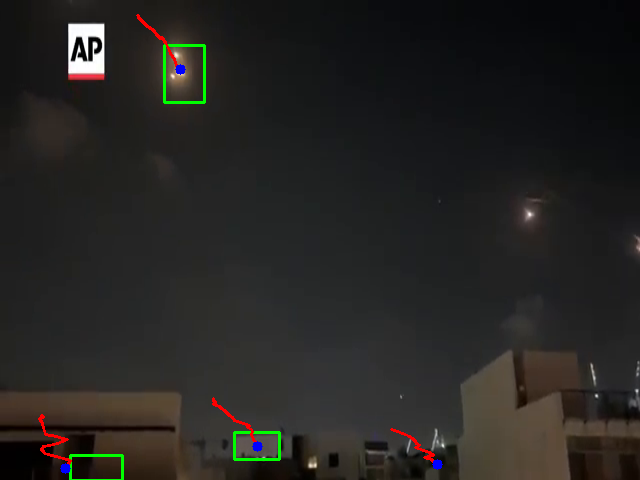

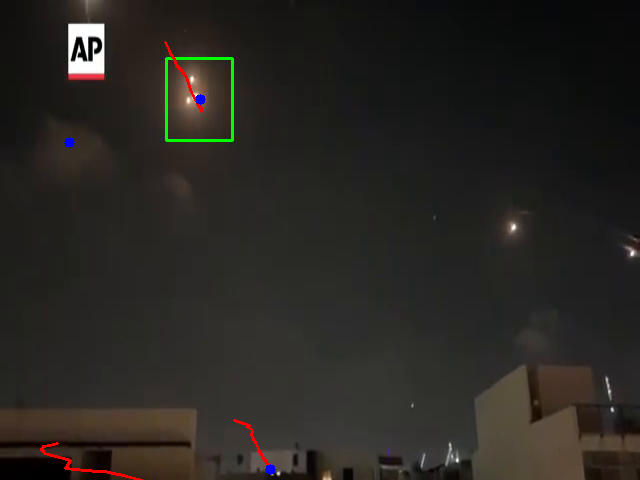

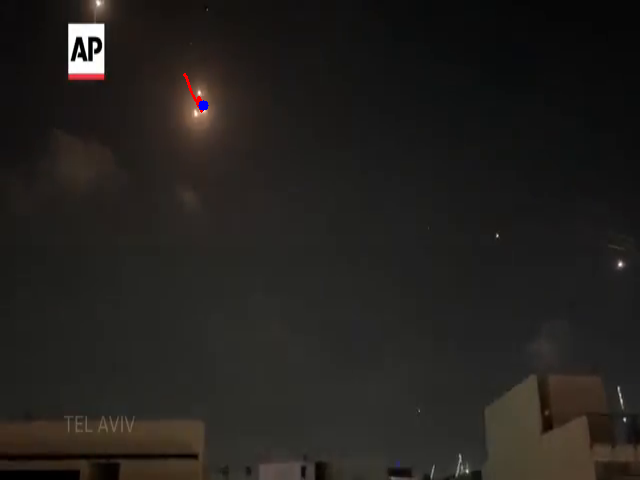

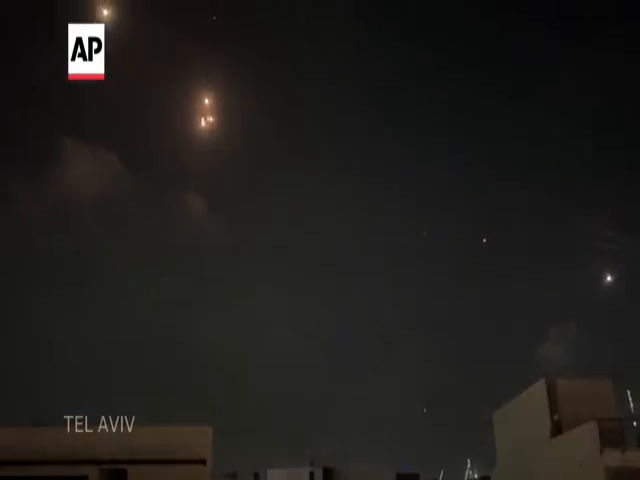

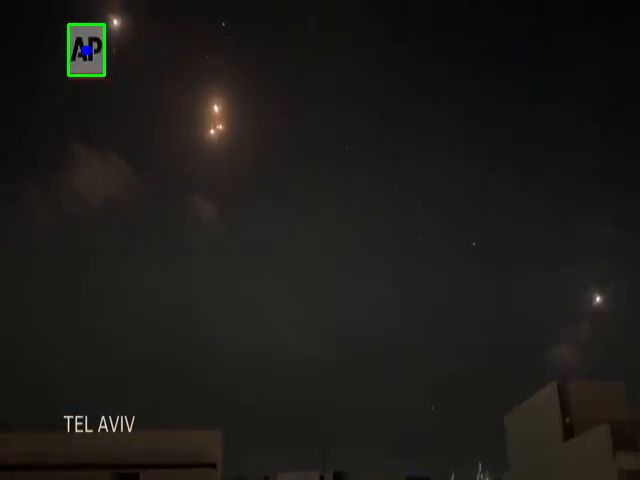

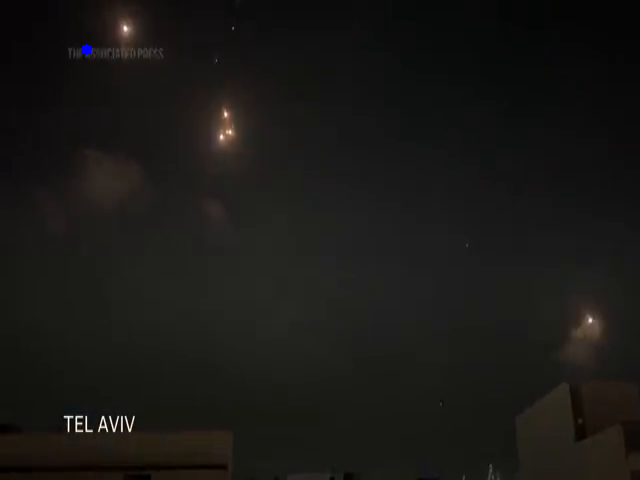

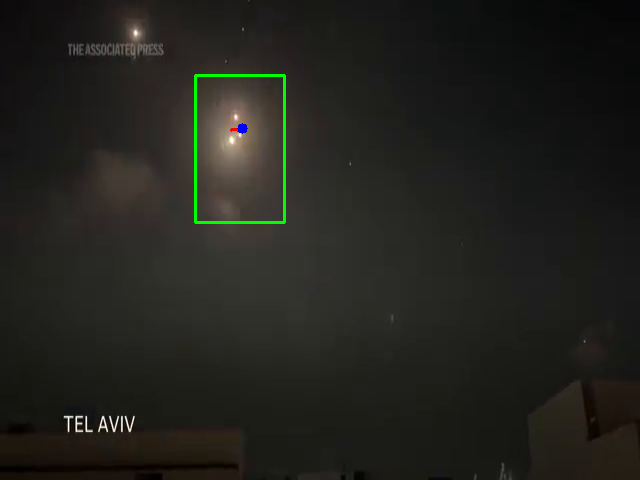

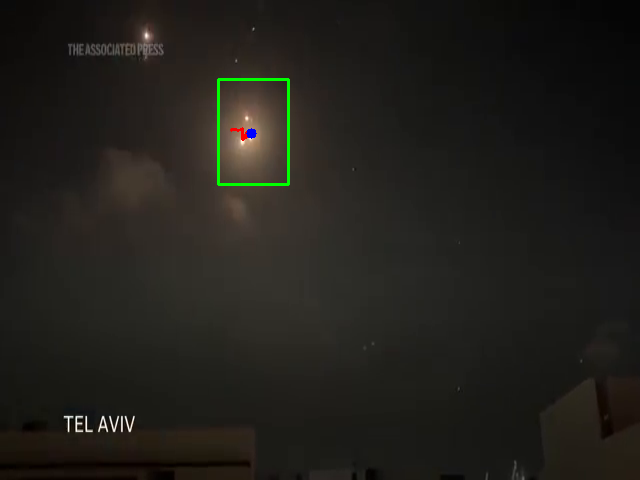

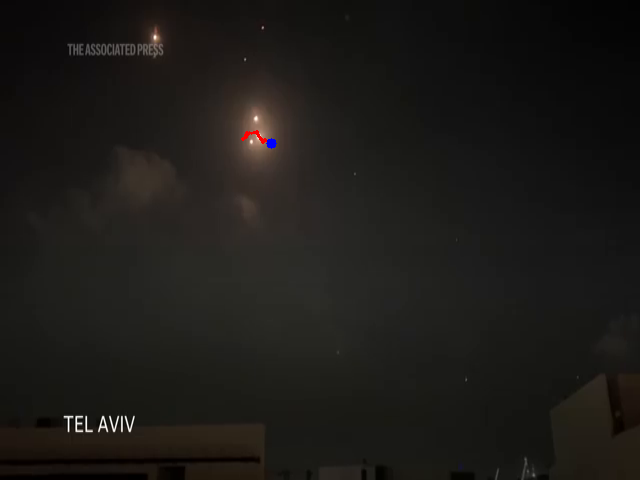

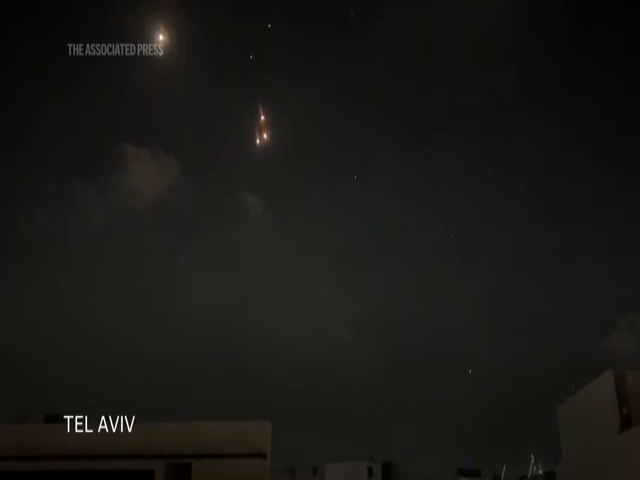

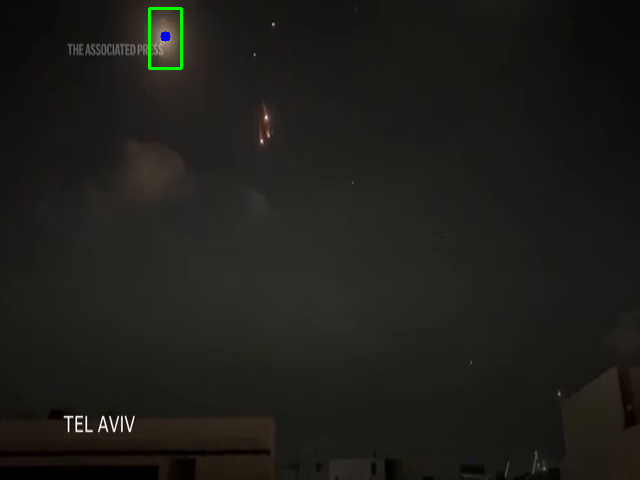

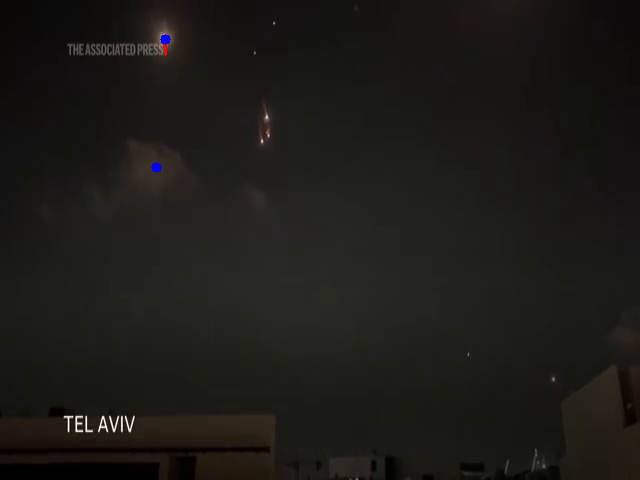

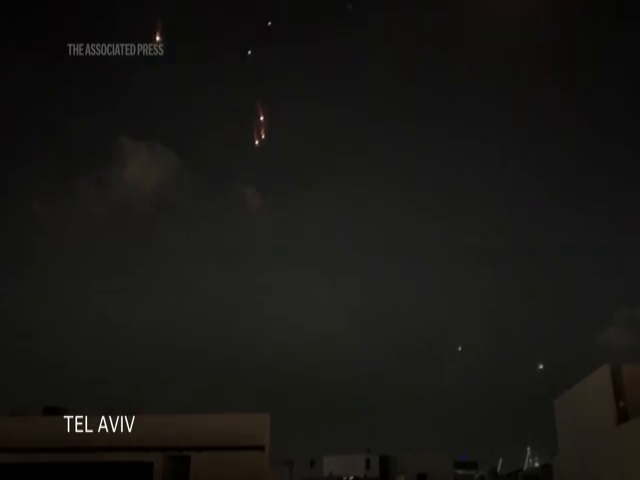

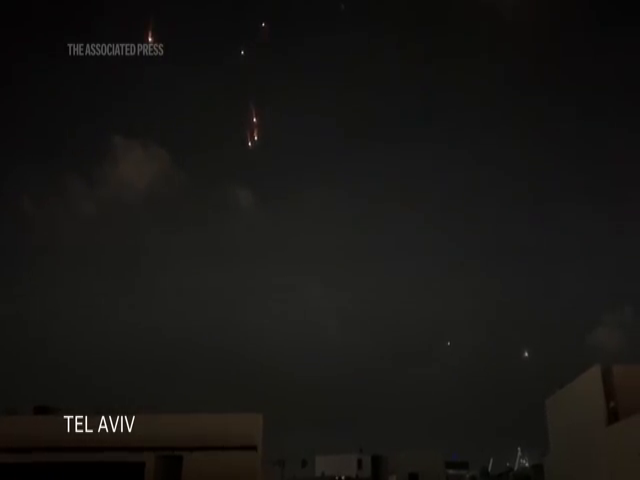

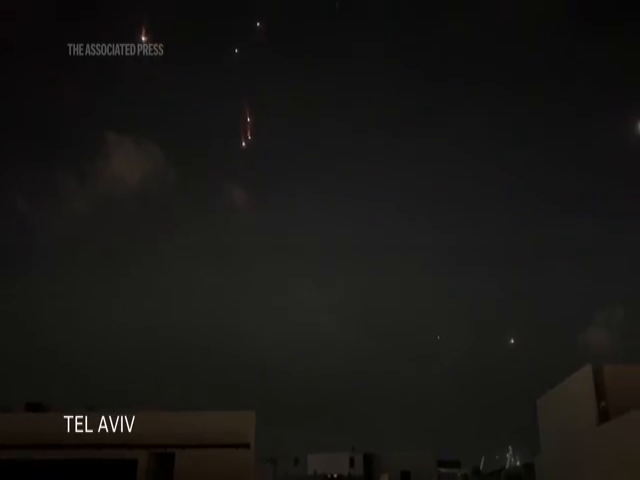

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# ---------------- VIDEO PATH ----------------
video_path = "Video_Playback.mp4"

cap = cv2.VideoCapture(video_path)
fgbg = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=40)

# ---------------- VIDEO SAVE ----------------
PROCESS_WIDTH = 640
PROCESS_HEIGHT = 480

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('tracking_output.avi', fourcc, 20.0,
                      (PROCESS_WIDTH, PROCESS_HEIGHT))

# ---------------- TRACKING CLASS ----------------
class TrackedObject:
    def __init__(self, x, y):
        self.kalman = cv2.KalmanFilter(4, 2)
        self.kalman.measurementMatrix = np.array([[1, 0, 0, 0],
                                                 [0, 1, 0, 0]], np.float32)

        self.kalman.transitionMatrix = np.array([[1, 0, 1, 0],
                                                [0, 1, 0, 1],
                                                [0, 0, 1, 0],
                                                [0, 0, 0, 1]], np.float32)

        self.kalman.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
        self.kalman.measurementNoiseCov = np.eye(2, dtype=np.float32)

        initial_state = np.array([[x], [y], [0], [0]], dtype=np.float32)
        self.kalman.statePre = initial_state
        self.kalman.statePost = initial_state

        self.predicted = (int(x), int(y))
        self.trace = []
        self.skipped_frames = 0

    def predict(self):
        prediction = self.kalman.predict()
        self.predicted = (int(prediction[0]), int(prediction[1]))
        return self.predicted

    def update(self, cx, cy):
        measured = np.array([[np.float32(cx)], [np.float32(cy)]])
        self.kalman.correct(measured)
        self.skipped_frames = 0


tracked_objects = []

# ---------------- FRAME LIMIT ----------------
frame_count = 0
max_frames = 200

# ---------------- MAIN LOOP ----------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (PROCESS_WIDTH, PROCESS_HEIGHT))

    fgmask = fgbg.apply(frame)
    _, thresh = cv2.threshold(fgmask, 200, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detections = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, w, h = cv2.boundingRect(cnt)
            detections.append((x + w // 2, y + h // 2, x, y, w, h))

    # Prediction
    for obj in tracked_objects:
        obj.predict()
        obj.skipped_frames += 1

    # Matching
    for (cx, cy, x, y, w, h) in detections:
        matched = False
        for obj in tracked_objects:
            px, py = obj.predicted
            dist = np.sqrt((cx - px)**2 + (cy - py)**2)

            if dist < 60:
                obj.update(cx, cy)
                matched = True
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                break

        if not matched:
            tracked_objects.append(TrackedObject(cx, cy))

    # Draw
    active_objects = []
    for obj in tracked_objects:
        if obj.skipped_frames < 10:
            active_objects.append(obj)

            obj.trace.append(obj.predicted)
            if len(obj.trace) > 20:
                obj.trace.pop(0)

            for i in range(1, len(obj.trace)):
                cv2.line(frame, obj.trace[i - 1], obj.trace[i], (0, 0, 255), 2)

            cv2.circle(frame, obj.predicted, 5, (255, 0, 0), -1)

    tracked_objects = active_objects

    # Show some frames
    if frame_count % 10 == 0:
        cv2_imshow(frame)

    out.write(frame)

    frame_count += 1
    if frame_count > max_frames:
        break

# ---------------- CLEANUP ----------------
cap.release()
out.release()

In [4]:
from google.colab import files
files.download("tracking_output.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>